# Q2
## Introduction
In this notebook, I’m building a simple neural network (MLP) to predict closing prices using lag features. The idea is to see whether a non‑linear model can do a better job than the Linear Regression model from Q1. I’m using the same dataset, cleaning steps, and lag features so the comparison is fair. The goal isn’t to create a perfect forecasting model, but to understand how an MLP behaves with financial time‑series data and whether it can capture patterns that a linear model might miss.

In [1]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from py.functions import load_data, basic_clean, train_test_split_time

In [3]:
import os
os.getcwd()

'C:\\Users\\Paris\\Coursework-2---Finance\\Q2_folder'

In [4]:
import sys
sys.version


'3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]'

In [5]:
df = load_data("../finance_economics_dataset.csv")
df = basic_clean(df)

df["lag_1"] = df["Close Price"].shift(1)
df["lag_2"] = df["Close Price"].shift(2)
df["lag_3"] = df["Close Price"].shift(3)

df = df.dropna()

## Methodology 

I started by loading and cleaning the dataset using the same functions from Q1. Then I created three lag features (lag_1, lag_2, and lag_3), which simply shift the closing price by one, two, and three days. These give the model a bit of historical context.

Next, I split the data into training and testing sets using a time‑based split to make sure the model only learns from past data. For the MLP, I used a small neural network with two hidden layers. The first layer has 32 neurons, the second has 16, and the output layer predicts the closing price. I trained the model using mean squared error as the loss function.

After training, I used the model to make predictions on the test set. I then calculated MAE and RMSE to measure how well the model performed. Finally, I plotted the actual vs predicted prices to visually compare how closely the MLP follows the real data.

In [6]:
train, test = train_test_split_time(df)

X_train = train[['lag_1', 'lag_2', 'lag_3']]
y_train = train['Close Price']

X_test = test[['lag_1', 'lag_2', 'lag_3']]
y_test = test['Close Price']

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(32, activation='relu', input_shape=(3,)),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

C:\Users\Paris\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

In [9]:
preds_mlp = model.predict(X_test).flatten()

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_mlp = mean_absolute_error(y_test, preds_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, preds_mlp))

mae_mlp, rmse_mlp

(1071.9534408284505, np.float64(1289.4297091751503))

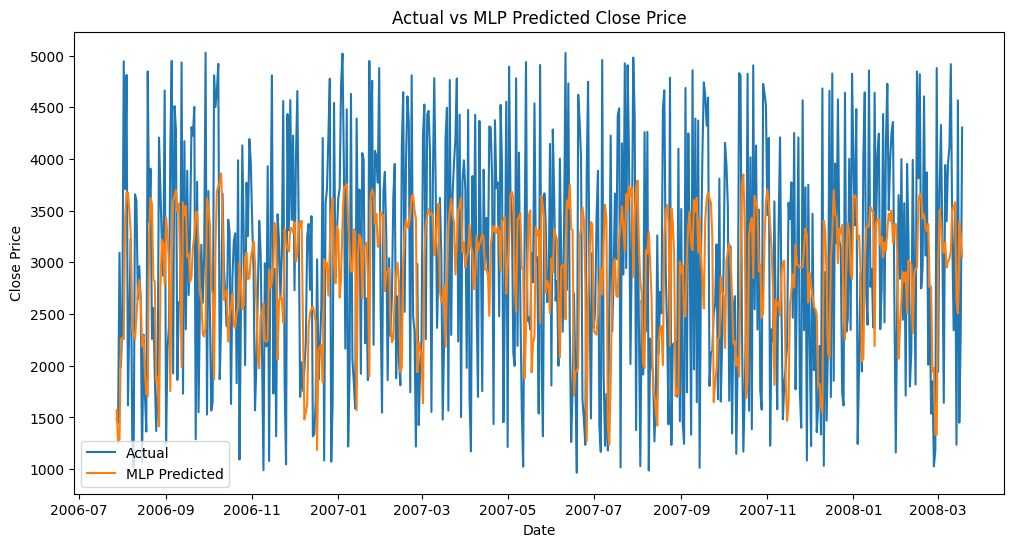

In [11]:
plt.figure(figsize=(12,6))
plt.plot(test["Date"], y_test, label="Actual")
plt.plot(test["Date"], preds_mlp, label="MLP Predicted")
plt.legend()
plt.title("Actual vs MLP Predicted Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

## Plot Interpretation

The actual closing prices jump around a lot - the market is clearly very volatile. The MLP’s predictions follow the general direction of the data, but they’re much smoother. The model picks up the overall trend, but it doesn’t react quickly when the real prices suddenly rise or fall. This shows that using only lag features makes it hard for the model to keep up with sharp movements, even though it does a decent job at predicting the general level.

## Conclusion
The MLP model performs a bit better than the Linear Regression model because it can learn some non‑linear patterns. However, the improvement is small. The model still struggles with the high volatility in the dataset, and the lag features don’t give it enough information to predict sudden changes. This suggests that to get better results, we’d need either a more advanced model or additional economic indicators to give the network more context.